# Petrol Price Prediction using Machine Learning

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

## Loading data

In [2]:
df = pd.read_csv(r"C:\Users\chara\Downloads\petrol_price_ml_dataset.csv")

In [3]:
# Printing first 5 rows of dataset
df.head()

,Date,Crude_Oil_Price_USD,USD_INR,Demand_Index,Tax_Rate,Petrol_Price_INR
0,2017-01-01,79.97,71.41,75,54,148.88
1,2017-01-02,73.62,73.91,62,46,140.48
2,2017-01-03,81.48,74.05,57,47,141.00
3,2017-01-04,90.23,75.42,54,46,147.88
4,2017-01-05,72.66,69.90,93,47,137.01


In [4]:
# Printing last 5 rows of dataset
df.tail()

,Date,Crude_Oil_Price_USD,USD_INR,Demand_Index,Tax_Rate,Petrol_Price_INR
3995,2027-12-10,75.28,80.63,65,49,146.13
3996,2027-12-11,54.22,74.98,60,51,128.44
3997,2027-12-12,71.80,71.49,91,47,137.35
3998,2027-12-13,91.43,78.96,57,52,157.52
3999,2027-12-14,78.61,80.23,82,49,149.77


In [5]:
# Shape of the dataset
df.shape

(4000, 6)

In [6]:
# information regarding dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 4000 non-null   object 
 1   Crude_Oil_Price_USD  4000 non-null   float64
 2   USD_INR              4000 non-null   float64
 3   Demand_Index         4000 non-null   int64  
 4   Tax_Rate             4000 non-null   int64  
 5   Petrol_Price_INR     4000 non-null   float64
dtypes: float64(3), int64(2), object(1)
memory usage: 187.6+ KB


In [7]:
# Checking for missing values
df.isnull().sum()

Date                   0
Crude_Oil_Price_USD    0
USD_INR                0
Demand_Index           0
Tax_Rate               0
Petrol_Price_INR       0
dtype: int64

In [8]:
# Statistical measure
df.describe()

,Crude_Oil_Price_USD,USD_INR,Demand_Index,Tax_Rate,Petrol_Price_INR
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,75.193168,73.921400,74.311000,49.494250,143.859753
std,9.971581,3.050384,14.370644,2.903115,7.410179
min,42.590000,62.930000,50.000000,45.000000,120.850000
25%,68.480000,71.877500,62.000000,47.000000,138.720000
50%,75.210000,73.910000,74.000000,50.000000,143.775000
75%,81.730000,76.020000,87.000000,52.000000,148.922500
max,114.260000,84.590000,99.000000,54.000000,169.240000


## Convert Date Column

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values("Date")

df.set_index("Date", inplace=True)

In [10]:
df.head()

,Crude_Oil_Price_USD,USD_INR,Demand_Index,Tax_Rate,Petrol_Price_INR
Date,,,,,
2017-01-01,79.97,71.41,75,54,148.88
2017-01-02,73.62,73.91,62,46,140.48
2017-01-03,81.48,74.05,57,47,141.00
2017-01-04,90.23,75.42,54,46,147.88
2017-01-05,72.66,69.90,93,47,137.01


In [11]:
# Select the target variable
data = df['Petrol_Price_INR']

data.head()

Date
2017-01-01    148.88
2017-01-02    140.48
2017-01-03    141.00
2017-01-04    147.88
2017-01-05    137.01
Name: Petrol_Price_INR, dtype: float64

## Visualize Petrol Price Trend

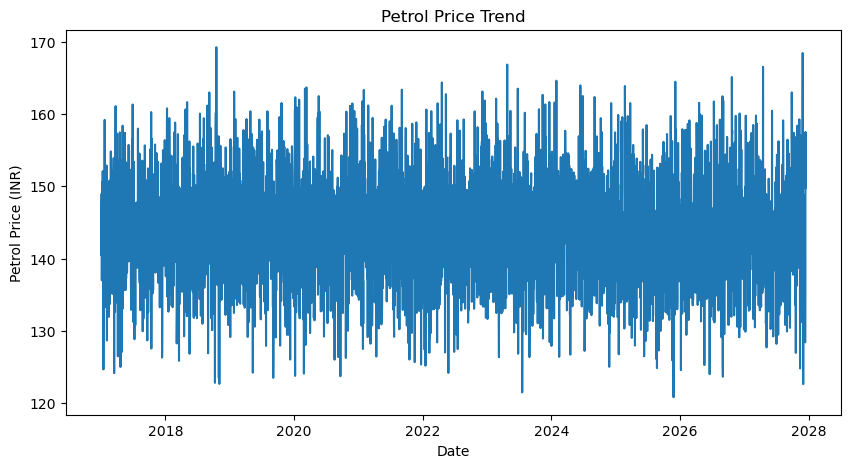

In [12]:
plt.figure(figsize=(10,5))

plt.plot(data)

plt.title("Petrol Price Trend")

plt.xlabel("Date")
plt.ylabel("Petrol Price (INR)")

plt.show()

## Train Test Split

In [13]:
train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]

print("Train Size:", len(train))
print("Test Size:", len(test))

Train Size: 3200
Test Size: 800


## Train ARIMA Model

In [14]:
model = ARIMA(train, order=(5,1,0))

model_fit = model.fit()

print(model_fit.summary())

C:\Users\chara\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\chara\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\chara\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       Petrol_Price_INR   No. Observations:                 3200
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -11159.574
Date:                Thu, 12 Mar 2026   AIC                          22331.148
Time:                        21:51:21   BIC                          22367.572
Sample:                    01-01-2017   HQIC                         22344.207
                         - 10-05-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8409      0.017    -48.389      0.000      -0.875      -0.807
ar.L2         -0.6474      0.022    -28.958      0.000      -0.691      -0.604
ar.L3         -0.4917      0.024    -20.475      0.0

## Predict Test Data

In [15]:
predictions = model_fit.forecast(steps=len(test))

predictions

2025-10-06    142.501709
2025-10-07    143.545264
2025-10-08    144.152147
2025-10-09    143.139376
2025-10-10    144.457501
                 ...    
2027-12-10    143.924861
2027-12-11    143.924861
2027-12-12    143.924861
2027-12-13    143.924861
2027-12-14    143.924861
Freq: D, Name: predicted_mean, Length: 800, dtype: float64

## Evaluate The Model

In [16]:
mse = mean_squared_error(test, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 59.058394037396845


## Plot Actual vs Predict Prices

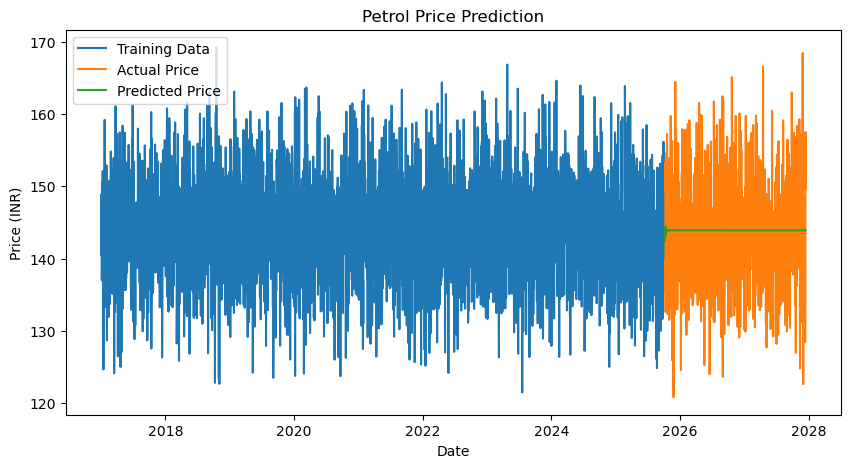

In [17]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train, label="Training Data")

plt.plot(test.index, test, label="Actual Price")

plt.plot(test.index, predictions, label="Predicted Price")

plt.legend()

plt.title("Petrol Price Prediction")

plt.xlabel("Date")
plt.ylabel("Price (INR)")

plt.show()

## Forecast Future Prices 

In [19]:
future_steps = 1000

future_forecast = model_fit.forecast(steps=future_steps)

future_forecast

2025-10-06    142.501709
2025-10-07    143.545264
2025-10-08    144.152147
2025-10-09    143.139376
2025-10-10    144.457501
                 ...    
2028-06-27    143.924861
2028-06-28    143.924861
2028-06-29    143.924861
2028-06-30    143.924861
2028-07-01    143.924861
Freq: D, Name: predicted_mean, Length: 1000, dtype: float64

## Create Future Dates 

In [20]:
future_dates = pd.date_range(start=data.index[-1], periods=future_steps)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Petrol_Price": future_forecast
})

forecast_df.head()

,Date,Predicted_Petrol_Price
2025-10-06,2027-12-14,142.501709
2025-10-07,2027-12-15,143.545264
2025-10-08,2027-12-16,144.152147
2025-10-09,2027-12-17,143.139376
2025-10-10,2027-12-18,144.457501


## Extract Prediction for 2027

In [22]:
prediction_2027 = forecast_df[
    forecast_df['Date'].dt.year == 2027
].reset_index(drop=True)

prediction_2027

,Date,Predicted_Petrol_Price
0,2027-12-14,142.501709
1,2027-12-15,143.545264
2,2027-12-16,144.152147
3,2027-12-17,143.139376
4,2027-12-18,144.457501
5,2027-12-19,144.231914
6,2027-12-20,143.692761
7,2027-12-21,143.887652
8,2027-12-22,143.902698
9,2027-12-23,143.891975


## Average Petrol Price in 2027

In [23]:
avg_price_2027 = prediction_2027["Predicted_Petrol_Price"].mean()

print("Average predicted petrol price in 2027:", avg_price_2027)

Average predicted petrol price in 2027: 143.82603162365797


## Plotting Future Forecast

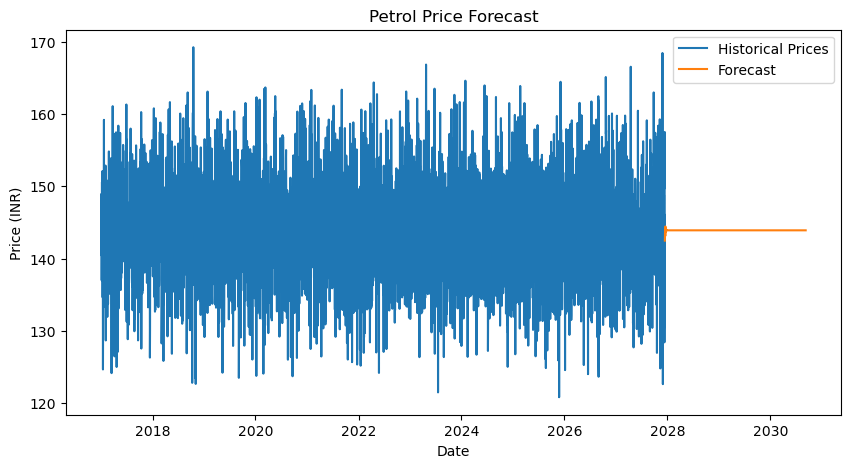

In [24]:
plt.figure(figsize=(10,5))

plt.plot(data.index, data, label="Historical Prices")

plt.plot(forecast_df["Date"], forecast_df["Predicted_Petrol_Price"], label="Forecast")

plt.legend()

plt.title("Petrol Price Forecast")

plt.xlabel("Date")
plt.ylabel("Price (INR)")

plt.show()